In [1]:
!pip -q install -U git+https://github.com/qubvel/segmentation_models.pytorch

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account

In [2]:
"""
Cell 1: Import all required libraries and set random seeds
"""

import os
import json
from pathlib import Path
from typing import Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

✅ Libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True
Number of GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
"""
Cell 2: Complete configuration for training
"""

CONFIG = {
    # Architecture
    'model': {
        'encoder_name': 'resnet34',
        'encoder_weights': 'imagenet',
        'decoder_channels': [256, 128, 64, 32, 16],
        'decoder_attention_type': 'scse',
        'in_channels': 3,
        'classes': 1,
    },
    
    # Training
    'training': {
        'batch_size': 64,
        'max_epochs': 500,
        'optimizer': 'AdamW',
        'lr': 2e-4, # Increased LR from 1e-4 to 2e-4 to match larger batch size
        'weight_decay': 1e-4,
        'loss_weights': {'focal': 0.5, 'dice': 0.5},
        'mixed_precision': True,
    },
    
    # Learning rate schedule
    'lr_schedule': {
        'scheduler': 'ReduceLROnPlateau',
        'mode': 'min',
        'factor': 0.5,
        'patience': 5,
        'min_lr': 1e-7,
        # 'verbose': True,
    },
    
    # Early stopping
    'early_stopping': {
        'patience': 10,
        'min_delta': 1e-4,
        'monitor': 'val_dice',
        'mode': 'max',
    },
    
    # Data
    'data': {
        'input_size': (256, 256),
        'num_workers': 2, # Keep at 2 for Kaggle stability
        'pin_memory': True,
        'persistent_workers': True,
    },
    
    # Hardware
    'hardware': {
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'num_gpus': torch.cuda.device_count(),
    },
    
    # Paths
    'paths': {
        'data_root': Path("/kaggle/input/isic-2018-task-1-segmentation"),
        'output_dir': Path("/kaggle/working"),
    }
}

# Data paths
DATA_ROOT = CONFIG['paths']['data_root']
IMG_DIRS = {
    "train": DATA_ROOT / "ISIC2018_Task1-2_Training_Input",
    "val": DATA_ROOT / "ISIC2018_Task1-2_Validation_Input",
    "test": DATA_ROOT / "ISIC2018_Task1-2_Test_Input",
}
MASK_DIRS = {
    "train": DATA_ROOT / "ISIC2018_Task1_Training_GroundTruth",
    "val": DATA_ROOT / "ISIC2018_Task1_Validation_GroundTruth",
    "test": DATA_ROOT / "ISIC2018_Task1_Test_GroundTruth",
}

print("✅ Configuration loaded!")
print(f"\n📊 Key Settings:")
print(f"  Device: {CONFIG['hardware']['device']}")
print(f"  Batch size: {CONFIG['training']['batch_size']}")
print(f"  Input size: {CONFIG['data']['input_size']}")
print(f"  Max epochs: {CONFIG['training']['max_epochs']}")
print(f"  Learning rate: {CONFIG['training']['lr']}")
print(f"  Mixed precision: {CONFIG['training']['mixed_precision']}")

✅ Configuration loaded!

📊 Key Settings:
  Device: cuda
  Batch size: 64
  Input size: (256, 256)
  Max epochs: 500
  Learning rate: 0.0002
  Mixed precision: True


In [4]:
"""
Cell 3: Dataset and data augmentation
"""

class ISICDataset(Dataset):
    """ISIC 2018 Skin Lesion Segmentation Dataset"""
    
    def __init__(self, img_dir: Path, mask_dir: Path, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # Get image filenames
        self.img_files = sorted([f for f in img_dir.glob("*.jpg")])
        
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.img_files[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        
        # Load mask (ground truth)
        mask_name = img_path.stem + "_segmentation.png"
        mask_path = self.mask_dir / mask_name
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 127).astype(np.float32)  # Binarize: {0, 1}
        
        # Apply augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Add channel dimension to mask: (H, W) -> (1, H, W)
        mask = mask.unsqueeze(0) if len(mask.shape) == 2 else mask
        
        return image, mask


def get_transforms(phase: str, input_size: Tuple[int, int]):
    """Get augmentation transforms for train/val/test"""
    
    if phase == 'train':
        return A.Compose([
            A.Resize(*input_size),
            
            # 1. Geometric Transforms (Rigid)
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Transpose(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1, 
                scale_limit=0.2, 
                rotate_limit=30, 
                border_mode=0, 
                p=0.7
            ),
            
            # 2. Geometric Transforms (Non-rigid / Distortion)
            A.OneOf([
                A.ElasticTransform(
                    alpha=120, 
                    sigma=120 * 0.05, 
                    alpha_affine=120 * 0.03, 
                    p=1.0
                ),
                A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
                A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=1.0),
            ], p=0.5),
            
            # 3. Color & Lighting (Crucial for skin variations)
            A.OneOf([
                A.RandomBrightnessContrast(
                    brightness_limit=0.2, 
                    contrast_limit=0.2, 
                    p=1.0
                ),
                A.RandomGamma(gamma_limit=(80, 120), p=1.0),
                A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0), # Contrast Limited Adaptive Histogram Equalization
            ], p=0.5),
            
            A.OneOf([
                A.HueSaturationValue(
                    hue_shift_limit=20, 
                    sat_shift_limit=30, 
                    val_shift_limit=20, 
                    p=1.0
                ),
                A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1.0),
            ], p=0.5),
            
            # 4. Noise, Blur & Artifacts (Robustness)
            A.OneOf([
                A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
                A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                A.MotionBlur(blur_limit=3, p=1.0),
                A.MedianBlur(blur_limit=3, p=1.0),
            ], p=0.3),
            
            A.OneOf([
                A.ImageCompression(quality_lower=80, quality_upper=100, p=1.0),
                A.ISONoise(p=1.0),
            ], p=0.2),
            
            # 5. Regularization (Cutout/Dropout)
            # Helps model learn context and not rely on specific features
            A.CoarseDropout(
                max_holes=8, 
                max_height=32, 
                max_width=32, 
                min_holes=1, 
                min_height=8, 
                min_width=8, 
                fill_value=0, 
                p=0.2
            ),

            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:  # val or test
        return A.Compose([
            A.Resize(*input_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])

print("✅ Dataset class and augmentation defined!")

✅ Dataset class and augmentation defined!


In [5]:
"""
Cell 4: Create datasets and dataloaders
"""

# Create datasets
train_dataset = ISICDataset(
    IMG_DIRS['train'], 
    MASK_DIRS['train'], 
    transform=get_transforms('train', CONFIG['data']['input_size'])
)
val_dataset = ISICDataset(
    IMG_DIRS['val'], 
    MASK_DIRS['val'], 
    transform=get_transforms('val', CONFIG['data']['input_size'])
)

print(f"📦 Dataset sizes:")
print(f"  Train: {len(train_dataset):,} images")
print(f"  Val:   {len(val_dataset):,} images")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=True,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=CONFIG['data']['pin_memory'],
    persistent_workers=CONFIG['data']['persistent_workers'],
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=CONFIG['data']['pin_memory'],
    persistent_workers=CONFIG['data']['persistent_workers'],
)

print(f"\n🔄 DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")

# Visualize a sample
sample_img, sample_mask = train_dataset[0]
print(f"\n🖼️  Sample shapes:")
print(f"  Image: {sample_img.shape}")
print(f"  Mask:  {sample_mask.shape}")

📦 Dataset sizes:
  Train: 2,585 images
  Val:   554 images

🔄 DataLoaders created:
  Train batches: 41
  Val batches:   9

🖼️  Sample shapes:
  Image: torch.Size([3, 256, 256])
  Mask:  torch.Size([1, 256, 256])


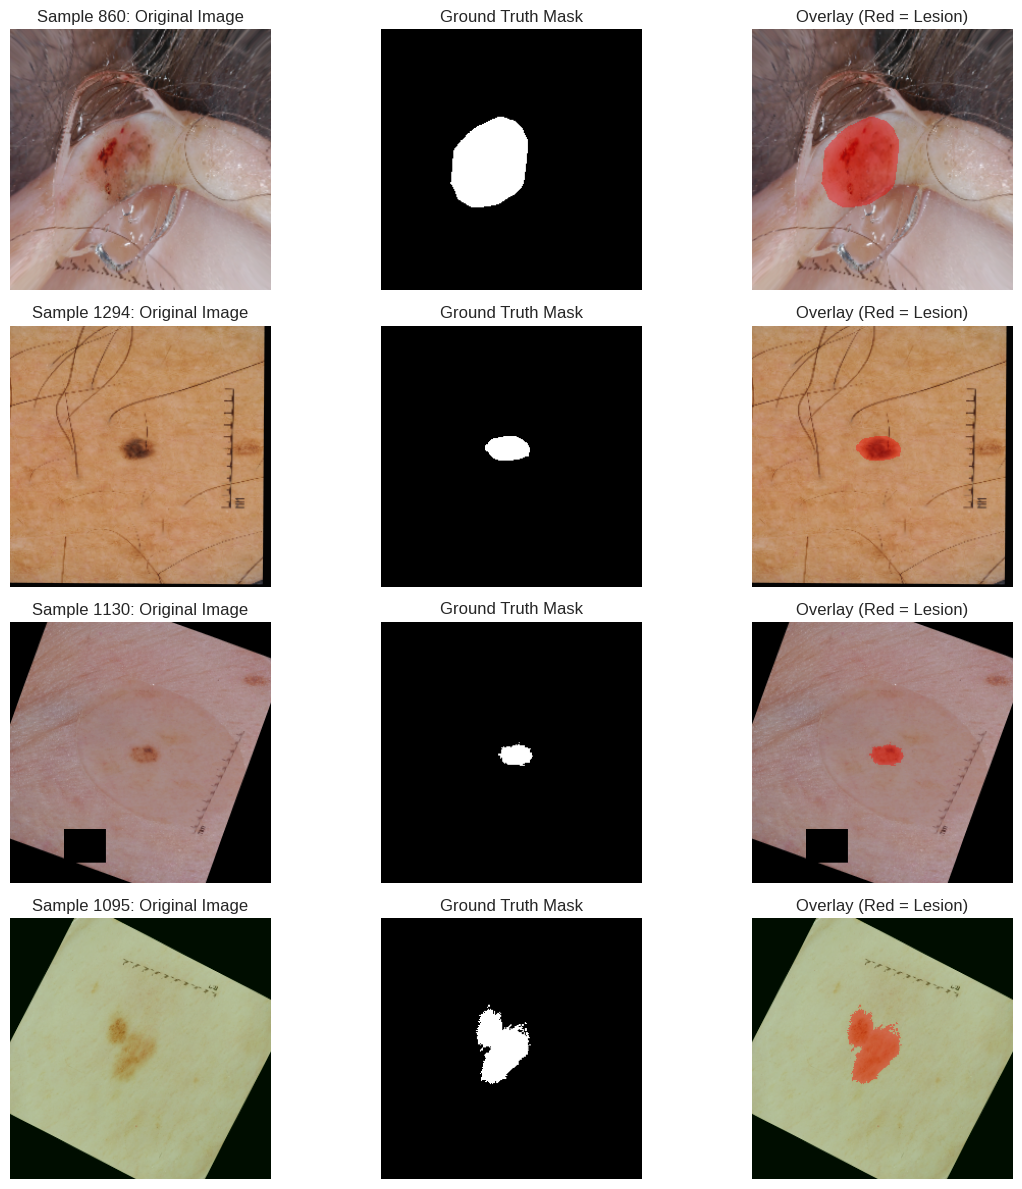

✅ Sample visualization complete!


In [6]:
"""
Cell 5: Visualize sample images and masks
"""

def visualize_samples(dataset, num_samples=4):
    """Visualize random samples from dataset"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))
    
    # Denormalization function
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image, mask = dataset[idx]
        
        # Denormalize image
        img_np = image.numpy().transpose(1, 2, 0)
        img_np = (img_np * std + mean).clip(0, 1)
        
        # Mask
        mask_np = mask.squeeze().numpy()
        
        # Overlay
        overlay = img_np.copy()
        overlay[mask_np > 0.5] = [1, 0, 0]  # Red for lesion
        overlay = 0.6 * img_np + 0.4 * overlay
        
        # Plot
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Sample {idx}: Original Image')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay (Red = Lesion)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset, num_samples=4)
print("✅ Sample visualization complete!")

In [7]:
"""
Cell 6: Create U-Net model with ResNet34 + SCSE Attention
"""

def create_model(config: Dict) -> nn.Module:
    """Create U-Net model with ResNet34 + SCSE Attention"""
    model_cfg = config['model']
    
    model = smp.Unet(
        encoder_name=model_cfg['encoder_name'],
        encoder_weights=model_cfg['encoder_weights'],
        decoder_attention_type=model_cfg['decoder_attention_type'],
        in_channels=model_cfg['in_channels'],
        classes=model_cfg['classes'],
    )
    
    return model


model = create_model(CONFIG)
device = torch.device(CONFIG['hardware']['device'])

# Multi-GPU if available
if CONFIG['hardware']['num_gpus'] > 1:
    model = nn.DataParallel(model)
    print(f"🚀 Using {CONFIG['hardware']['num_gpus']} GPUs with DataParallel")

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🏗️  Model Architecture:")
print(f"  Encoder: {CONFIG['model']['encoder_name']}")
print(f"  Decoder Attention: {CONFIG['model']['decoder_attention_type']}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024**2:.1f} MB (FP32)")

print("\n✅ Model created and moved to device!")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

🚀 Using 2 GPUs with DataParallel

🏗️  Model Architecture:
  Encoder: resnet34
  Decoder Attention: scse
  Total parameters: 24,550,360
  Trainable parameters: 24,550,360
  Model size: ~93.7 MB (FP32)

✅ Model created and moved to device!


In [8]:
"""
Cell 7: Loss functions (Updated & Optimized)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance and hard examples.
    FL(p_t) = (1 - p_t)^gamma * log(p_t)
    
    Args:
        alpha (float, optional): Weighting factor for the rare class (lesion). 
                                 Default: None (Let Dice Loss handle class balance).
        gamma (float): Focusing parameter for hard examples. Default: 2.0.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: Logits (chưa qua Sigmoid), targets: Binary Mask {0, 1}
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss) # pt là xác suất dự đoán đúng
        
        # Tính Focal term: (1 - pt)^gamma
        focal_term = (1 - pt) ** self.gamma
        
        # Áp dụng Alpha (nếu có)
        if self.alpha is not None:
            # alpha cho lớp 1 (lesion), (1-alpha) cho lớp 0 (background)
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * focal_term * bce_loss
        else:
            loss = focal_term * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


def dice_loss(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    """
    Dice Loss (Soft Dice)
    logits: (B, 1, H, W) - raw logits from model
    targets: (B, 1, H, W) - binary mask {0, 1}
    """
    probs = torch.sigmoid(logits)
    targets = targets.float()
    
    # Tính Dice cho từng ảnh trong batch (dims=(1,2,3)) để tránh ảnh lớn lấn át ảnh nhỏ
    dims = (1, 2, 3)
    intersection = (probs * targets).sum(dims)
    union = probs.sum(dims) + targets.sum(dims)
    
    # Tính Dice Score cho từng ảnh
    dice_score = (2.0 * intersection + eps) / (union + eps)
    
    # Loss là trung bình của (1 - Dice) trên cả batch
    return 1.0 - dice_score.mean()


# --- Khởi tạo Loss Function ---
# Lưu ý: Set alpha=None vì Dice Loss đã làm rất tốt việc cân bằng lớp rồi.
# Chỉ cần Gamma=2.0 để model tập trung vào các pixel khó (biên/rìa).
focal_criterion = FocalLoss(alpha=None, gamma=2.0)


def combined_loss(pred: torch.Tensor, target: torch.Tensor, 
                  focal_weight: float = 0.5, dice_weight: float = 0.5) -> torch.Tensor:
    """
    Combined Loss: Weights * Focal + Weights * Dice
    """
    focal = focal_criterion(pred, target)
    dsc = dice_loss(pred, target)
    return focal_weight * focal + dice_weight * dsc


def dice_coefficient(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    """
    Dice Coefficient Metric (Macro-average: Tính từng ảnh rồi chia trung bình)
    """
    with torch.no_grad():
        probs = torch.sigmoid(pred)
        preds_binary = (probs > threshold).float()
        
        # Flatten về (Batch, -1) để tính tổng pixel cho từng ảnh
        preds_flat = preds_binary.view(preds_binary.size(0), -1)
        targets_flat = target.view(target.size(0), -1)
        
        intersection = (preds_flat * targets_flat).sum(1)
        union = preds_flat.sum(1) + targets_flat.sum(1)
        
        dice = (2.0 * intersection + 1e-7) / (union + 1e-7)
        return dice.mean().item()


def iou_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    """
    IoU (Jaccard) Metric (Macro-average)
    """
    with torch.no_grad():
        probs = torch.sigmoid(pred)
        preds_binary = (probs > threshold).float()
        
        preds_flat = preds_binary.view(preds_binary.size(0), -1)
        targets_flat = target.view(target.size(0), -1)
        
        intersection = (preds_flat * targets_flat).sum(1)
        union = preds_flat.sum(1) + targets_flat.sum(1) - intersection
        
        iou = (intersection + 1e-7) / (union + 1e-7)
        return iou.mean().item()

print("✅ Loss functions updated successfully!")
# In ra để double check
print(f"  Focal Config: Alpha={focal_criterion.alpha}, Gamma={focal_criterion.gamma}")
print(f"  Combined Loss: {CONFIG['training']['loss_weights'].get('focal', 0.5)} × Focal + {CONFIG['training']['loss_weights']['dice']} × Dice")

✅ Loss functions updated successfully!
  Focal Config: Alpha=None, Gamma=2.0
  Combined Loss: 0.5 × Focal + 0.5 × Dice


In [9]:
"""
Cell 8: Setup optimizer and learning rate scheduler
"""

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['training']['lr'],
    weight_decay=CONFIG['training']['weight_decay']
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=CONFIG['lr_schedule']['mode'],
    factor=CONFIG['lr_schedule']['factor'],
    patience=CONFIG['lr_schedule']['patience'],
    min_lr=CONFIG['lr_schedule']['min_lr'],
    # verbose=CONFIG['lr_schedule']['verbose'],
)

print("✅ Optimizer and scheduler created!")
print(f"  Optimizer: {CONFIG['training']['optimizer']}")
print(f"  Initial LR: {CONFIG['training']['lr']}")
print(f"  Weight decay: {CONFIG['training']['weight_decay']}")
print(f"  Scheduler: {CONFIG['lr_schedule']['scheduler']}")
print(f"  LR reduction factor: {CONFIG['lr_schedule']['factor']}")
print(f"  Patience: {CONFIG['lr_schedule']['patience']} epochs")

✅ Optimizer and scheduler created!
  Optimizer: AdamW
  Initial LR: 0.0002
  Weight decay: 0.0001
  Scheduler: ReduceLROnPlateau
  LR reduction factor: 0.5
  Patience: 5 epochs


In [10]:
"""
Cell 9: Training and validation functions
"""

class EarlyStopping:
    """Early stopping to stop training when monitored metric stops improving"""
    
    def __init__(self, patience: int, min_delta: float, mode: str = 'max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            return False
        
        if self.mode == 'max':
            improved = score > (self.best_score + self.min_delta)
        else:
            improved = score < (self.best_score - self.min_delta)
        
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        
        return self.early_stop


def train_one_epoch(model, loader, optimizer, scaler, device, loss_weights):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        with autocast(enabled=CONFIG['training']['mixed_precision']):
            logits = model(images)
            loss = combined_loss(
                logits, masks, 
                focal_weight=loss_weights['focal'],
                dice_weight=loss_weights['dice']
            )
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Metrics
        dice = dice_coefficient(logits, masks)
        iou = iou_score(logits, masks)
        running_loss += loss.item() * images.size(0)
        running_dice += dice * images.size(0)
        running_iou += iou * images.size(0)
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}'
        })
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_dice = running_dice / len(loader.dataset)
    epoch_iou = running_iou / len(loader.dataset)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate(model, loader, device, loss_weights):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Use autocast for validation as well to prevent type mismatch errors
            with autocast(enabled=CONFIG['training']['mixed_precision']):
                logits = model(images)
                loss = combined_loss(
                    logits, masks,
                    focal_weight=loss_weights['focal'],
                    dice_weight=loss_weights['dice']
                )
            
            dice = dice_coefficient(logits, masks)
            iou = iou_score(logits, masks)
            running_loss += loss.item() * images.size(0)
            running_dice += dice * images.size(0)
            running_iou += iou * images.size(0)
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_dice = running_dice / len(loader.dataset)
    epoch_iou = running_iou / len(loader.dataset)
    
    return epoch_loss, epoch_dice, epoch_iou

print("✅ Training functions defined!")

✅ Training functions defined!


In [11]:
"""
Cell 10: Main training loop
"""

# Initialize training components
scaler = GradScaler(enabled=CONFIG['training']['mixed_precision'])
early_stopping = EarlyStopping(
    patience=CONFIG['early_stopping']['patience'],
    min_delta=CONFIG['early_stopping']['min_delta'],
    mode=CONFIG['early_stopping']['mode']
)

# History tracking
history = {
    'train_loss': [],
    'train_dice': [],
    'train_iou': [],
    'val_loss': [],
    'val_dice': [],
    'val_iou': [],
    'lr': [],
}

best_val_dice = 0.0
best_model_path = CONFIG['paths']['output_dir'] / 'best_model.pth'

print("="*70)
print("🚀 STARTING TRAINING")
print("="*70)

# Training loop
for epoch in range(CONFIG['training']['max_epochs']):
    print(f"\n📍 Epoch {epoch+1}/{CONFIG['training']['max_epochs']}")
    print("-" * 70)
    
    # Train
    train_loss, train_dice, train_iou = train_one_epoch(
        model, train_loader, optimizer, scaler, device,
        CONFIG['training']['loss_weights']
    )
    
    # Validate
    val_loss, val_dice, val_iou = validate(
        model, val_loader, device,
        CONFIG['training']['loss_weights']
    )
    
    # Learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_iou'].append(train_iou)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['lr'].append(current_lr)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"  Train → Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
    print(f"  LR: {current_lr:.2e}")
    
    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': val_dice,
            'val_iou': val_iou,
            'config': CONFIG,
            'history': history,
        }, best_model_path)
        print(f"  ✅ Best model saved! (Val Dice: {val_dice:.4f})")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if early_stopping(val_dice):
        print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
        print(f"  Best Val Dice: {best_val_dice:.4f}")
        break

print("\n" + "="*70)
print("✅ TRAINING COMPLETED")
print("="*70)
print(f"🏆 Best Validation Dice: {best_val_dice:.4f}")
print(f"📁 Best model saved to: {best_model_path}")

🚀 STARTING TRAINING

📍 Epoch 1/500
----------------------------------------------------------------------


Training:   0%|          | 0/41 [00:00<?, ?it/s]

Validation:   0%|          | 0/9 [00:00<?, ?it/s]


📊 Epoch 1 Summary:
  Train → Loss: 0.3483 | Dice: 0.6694 | IoU: 0.5520
  Val   → Loss: 0.2714 | Dice: 0.8159 | IoU: 0.7157
  LR: 2.00e-04
  ✅ Best model saved! (Val Dice: 0.8159)

📍 Epoch 2/500
----------------------------------------------------------------------


Training:   0%|          | 0/41 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/9 [00:00<?, ?it/s]


📊 Epoch 51 Summary:
  Train → Loss: 0.0803 | Dice: 0.9124 | IoU: 0.8483
  Val   → Loss: 0.1098 | Dice: 0.8966 | IoU: 0.8318
  LR: 1.25e-05

📍 Epoch 52/500
----------------------------------------------------------------------


Training:   0%|          | 0/41 [00:00<?, ?it/s]

Validation:   0%|          | 0/9 [00:00<?, ?it/s]


📊 Epoch 52 Summary:
  Train → Loss: 0.0823 | Dice: 0.9101 | IoU: 0.8458
  Val   → Loss: 0.1094 | Dice: 0.8970 | IoU: 0.8323
  LR: 1.25e-05

⚠️  Early stopping triggered after 52 epochs
  Best Val Dice: 0.8972

✅ TRAINING COMPLETED
🏆 Best Validation Dice: 0.8972
📁 Best model saved to: /kaggle/working/best_model.pth



✅ Training curves saved to: /kaggle/working/training_curves.png


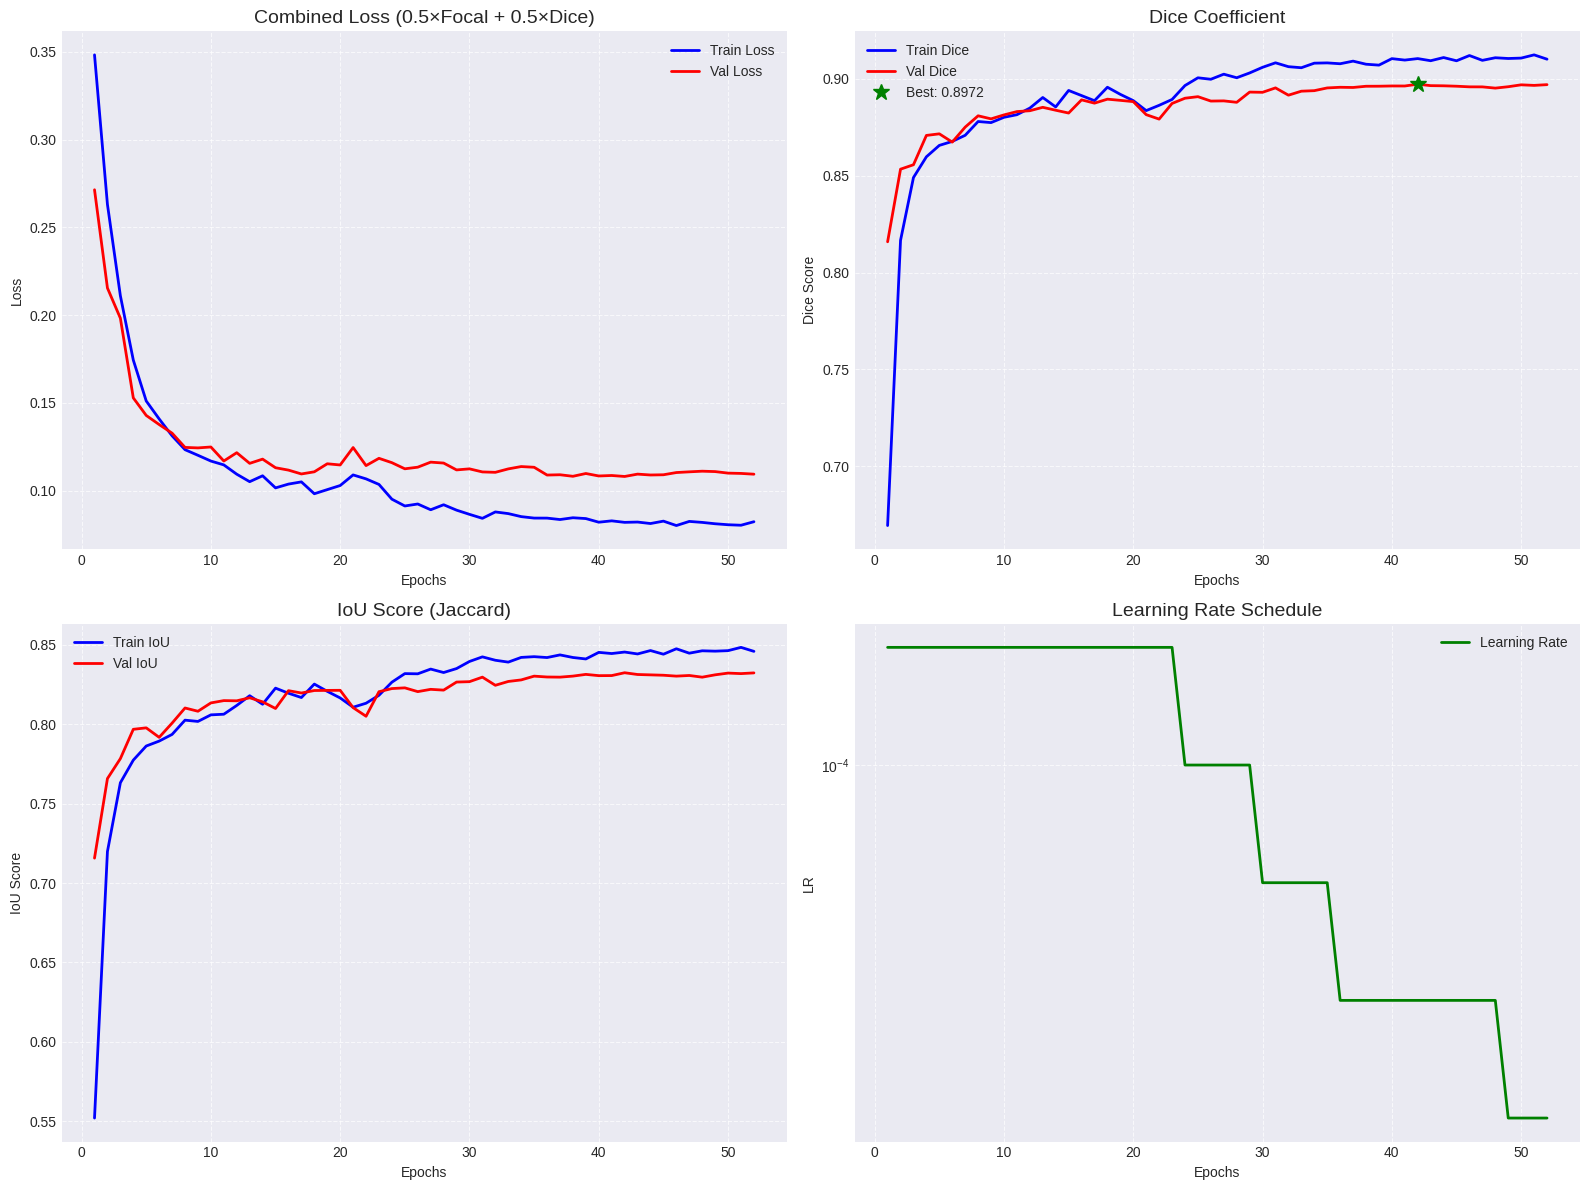

In [12]:
"""
Cell 11: Plot training curves (Simplified)
"""

def plot_training_curves(history: Dict, save_path: Path):
    """Plot simplified training curves (Loss, Dice, IoU, LR)"""
    
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax.set_title('Combined Loss (0.5×Focal + 0.5×Dice)', fontsize=14)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    # 2. Dice Score
    ax = axes[0, 1]
    ax.plot(epochs, history['train_dice'], 'b-', label='Train Dice', linewidth=2)
    ax.plot(epochs, history['val_dice'], 'r-', label='Val Dice', linewidth=2)
    
    # Mark best val dice
    if len(history['val_dice']) > 0:
        best_epoch = np.argmax(history['val_dice'])
        best_dice = history['val_dice'][best_epoch]
        ax.plot(best_epoch + 1, best_dice, 'g*', markersize=12, label=f'Best: {best_dice:.4f}')
    
    ax.set_title('Dice Coefficient', fontsize=14)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Dice Score')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    # 3. IoU Score
    ax = axes[1, 0]
    ax.plot(epochs, history['train_iou'], 'b-', label='Train IoU', linewidth=2)
    ax.plot(epochs, history['val_iou'], 'r-', label='Val IoU', linewidth=2)
    ax.set_title('IoU Score (Jaccard)', fontsize=14)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('IoU Score')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    # 4. Learning Rate
    ax = axes[1, 1]
    ax.plot(epochs, history['lr'], 'g-', label='Learning Rate', linewidth=2)
    ax.set_title('Learning Rate Schedule', fontsize=14)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('LR')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Training curves saved to: {save_path}")
    plt.show()


save_path = CONFIG['paths']['output_dir'] / 'training_curves.png'
plot_training_curves(history, save_path)

In [13]:
"""
Cell 12: Save training history to files
"""

# Save history as JSON
history_path = CONFIG['paths']['output_dir'] / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=4)
print(f"✅ Training history (JSON) saved to: {history_path}")

# Save history as CSV
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, len(history_df) + 1)
history_csv_path = CONFIG['paths']['output_dir'] / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"✅ Training history (CSV) saved to: {history_csv_path}")

# Display history dataframe
print("\n📊 Training History (Last 10 epochs):")
print(history_df[['epoch', 'train_dice', 'val_dice', 'train_loss', 'val_loss', 'lr']].tail(10))

✅ Training history (JSON) saved to: /kaggle/working/training_history.json
✅ Training history (CSV) saved to: /kaggle/working/training_history.csv

📊 Training History (Last 10 epochs):
    epoch  train_dice  val_dice  train_loss  val_loss        lr
42     43    0.909329  0.896468    0.082087  0.109399  0.000025
43     44    0.910969  0.896381    0.081241  0.108904  0.000025
44     45    0.909299  0.896171    0.082608  0.109031  0.000025
45     46    0.912011  0.895847    0.080092  0.110297  0.000025
46     47    0.909525  0.895827    0.082448  0.110705  0.000025
47     48    0.910867  0.895190    0.081885  0.111065  0.000025
48     49    0.910480  0.895909    0.081111  0.110845  0.000013
49     50    0.910687  0.896890    0.080553  0.109966  0.000013
50     51    0.912353  0.896598    0.080271  0.109798  0.000013
51     52    0.910124  0.896977    0.082279  0.109361  0.000013


In [14]:
"""
Cell 13: Print final configuration and training summary
"""

print("\n" + "="*70)
print("⚙️  FINAL TRAINING CONFIGURATION")
print("="*70)
print(json.dumps(CONFIG, indent=2, default=str))
print("="*70)

print("\n" + "="*70)
print("📈 TRAINING SUMMARY STATISTICS")
print("="*70)
print(f"\n🔢 Training Details:")
print(f"  Total Epochs Trained: {len(history['train_loss'])}")
print(f"  Total Training Time: ~{len(history['train_loss']) * len(train_loader) * CONFIG['training']['batch_size'] / 60:.1f} minutes (estimated)")

print(f"\n🏆 Best Performance:")
best_epoch = np.argmax(history['val_dice']) + 1
print(f"  Best Validation Dice: {max(history['val_dice']):.4f} (Epoch {best_epoch})")
print(f"  Best Validation IoU:  {history['val_iou'][best_epoch-1]:.4f} (Epoch {best_epoch})")

print(f"\n📊 Final Metrics (Last Epoch):")
print(f"  Training Dice:    {history['train_dice'][-1]:.4f}")
print(f"  Validation Dice:  {history['val_dice'][-1]:.4f}")
print(f"  Training IoU:     {history['train_iou'][-1]:.4f}")
print(f"  Validation IoU:   {history['val_iou'][-1]:.4f}")

print(f"\n📉 Final Loss:")
print(f"  Training Loss:    {history['train_loss'][-1]:.4f}")
print(f"  Validation Loss:  {history['val_loss'][-1]:.4f}")

print(f"\n🎓 Learning Rate:")
print(f"  Initial LR:  {CONFIG['training']['lr']:.2e}")
print(f"  Final LR:    {history['lr'][-1]:.2e}")

print(f"\n📁 Saved Files:")
print(f"  Best model:        {best_model_path}")
print(f"  Training curves:   {CONFIG['paths']['output_dir'] / 'training_curves.png'}")
print(f"  History (JSON):    {history_path}")
print(f"  History (CSV):     {history_csv_path}")

print("\n" + "="*70)
print("✅ TRAINING SCRIPT COMPLETED SUCCESSFULLY!")
print("="*70)


⚙️  FINAL TRAINING CONFIGURATION
{
  "model": {
    "encoder_name": "resnet34",
    "encoder_weights": "imagenet",
    "decoder_channels": [
      256,
      128,
      64,
      32,
      16
    ],
    "decoder_attention_type": "scse",
    "in_channels": 3,
    "classes": 1
  },
  "training": {
    "batch_size": 64,
    "max_epochs": 500,
    "optimizer": "AdamW",
    "lr": 0.0002,
    "weight_decay": 0.0001,
    "loss_weights": {
      "focal": 0.5,
      "dice": 0.5
    },
    "mixed_precision": true
  },
  "lr_schedule": {
    "scheduler": "ReduceLROnPlateau",
    "mode": "min",
    "factor": 0.5,
    "patience": 5,
    "min_lr": 1e-07
  },
  "early_stopping": {
    "patience": 10,
    "min_delta": 0.0001,
    "monitor": "val_dice",
    "mode": "max"
  },
  "data": {
    "input_size": [
      256,
      256
    ],
    "num_workers": 2,
    "pin_memory": true,
    "persistent_workers": true
  },
  "hardware": {
    "device": "cuda",
    "num_gpus": 2
  },
  "paths": {
    "data_roo

In [15]:
"""
Cell 14: Load best model and prepare test data
"""
# best_model_path = '/kaggle/working/best_model.pth'

# Load best model weights
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1} (Val Dice: {checkpoint['val_dice']:.4f})")
else:
    print(f"⚠️ Warning: Best model not found at {best_model_path}. Using current model weights.")

# Create test dataset and loader
test_dataset = ISICDataset(
    IMG_DIRS['test'], 
    MASK_DIRS['test'], 
    transform=get_transforms('test', CONFIG['data']['input_size'])
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=CONFIG['data']['pin_memory'],
    persistent_workers=CONFIG['data']['persistent_workers'],
)

print(f"📦 Test dataset size: {len(test_dataset)} images")

✅ Loaded best model from epoch 42 (Val Dice: 0.8972)
📦 Test dataset size: 555 images


In [16]:
"""
Cell 15: Evaluate on Test Set
"""
import gc

# --- Memory Cleanup Before Evaluation ---
# Extract info from checkpoint if it exists, then delete it to free RAM
best_val_dice_info = None
best_epoch_info = None

if 'checkpoint' in globals():
    print("ℹ️ Found checkpoint in memory. Extracting info and clearing to save RAM...")
    best_val_dice_info = checkpoint.get('val_dice')
    best_epoch_info = checkpoint.get('epoch')
    del checkpoint

# Clear other training artifacts to free memory
# Xóa các biến không cần thiết để giải phóng RAM
for var_name in ['optimizer', 'scheduler', 'scaler', 'train_loader', 'val_loader']:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()
print("🧹 Memory cleanup completed.")
# ----------------------------------------

def evaluate_test(model, loader, device):
    """Evaluate model on test set"""
    model.eval()
    running_dice = 0.0
    running_iou = 0.0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Testing")
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Use autocast for testing
            with autocast(enabled=CONFIG['training']['mixed_precision']):
                logits = model(images)
            
            dice = dice_coefficient(logits, masks)
            iou = iou_score(logits, masks)
            
            running_dice += dice * images.size(0)
            running_iou += iou * images.size(0)
            
            pbar.set_postfix({
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
            
            # Explicitly delete tensors to free memory immediately
            del images, masks, logits
    
    test_dice = running_dice / len(loader.dataset)
    test_iou = running_iou / len(loader.dataset)
    
    return test_dice, test_iou

print("🚀 Starting evaluation on Test Set...")
test_dice, test_iou = evaluate_test(model, test_loader, device)

print(f"\n🏆 Test Set Results:")
print(f"  Dice Score: {test_dice:.4f}")
print(f"  IoU Score:  {test_iou:.4f}")

# Save test results
test_results = {
    'test_dice': test_dice,
    'test_iou': test_iou,
    'best_val_dice': best_val_dice_info,
    'best_epoch': best_epoch_info
}

with open(CONFIG['paths']['output_dir'] / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=4)
print(f"✅ Test results saved to {CONFIG['paths']['output_dir'] / 'test_results.json'}")

ℹ️ Found checkpoint in memory. Extracting info and clearing to save RAM...
🧹 Memory cleanup completed.
🚀 Starting evaluation on Test Set...


Testing:   0%|          | 0/9 [00:00<?, ?it/s]


🏆 Test Set Results:
  Dice Score: 0.9021
  IoU Score:  0.8368
✅ Test results saved to /kaggle/working/test_results.json


📊 Visualizing random test predictions...


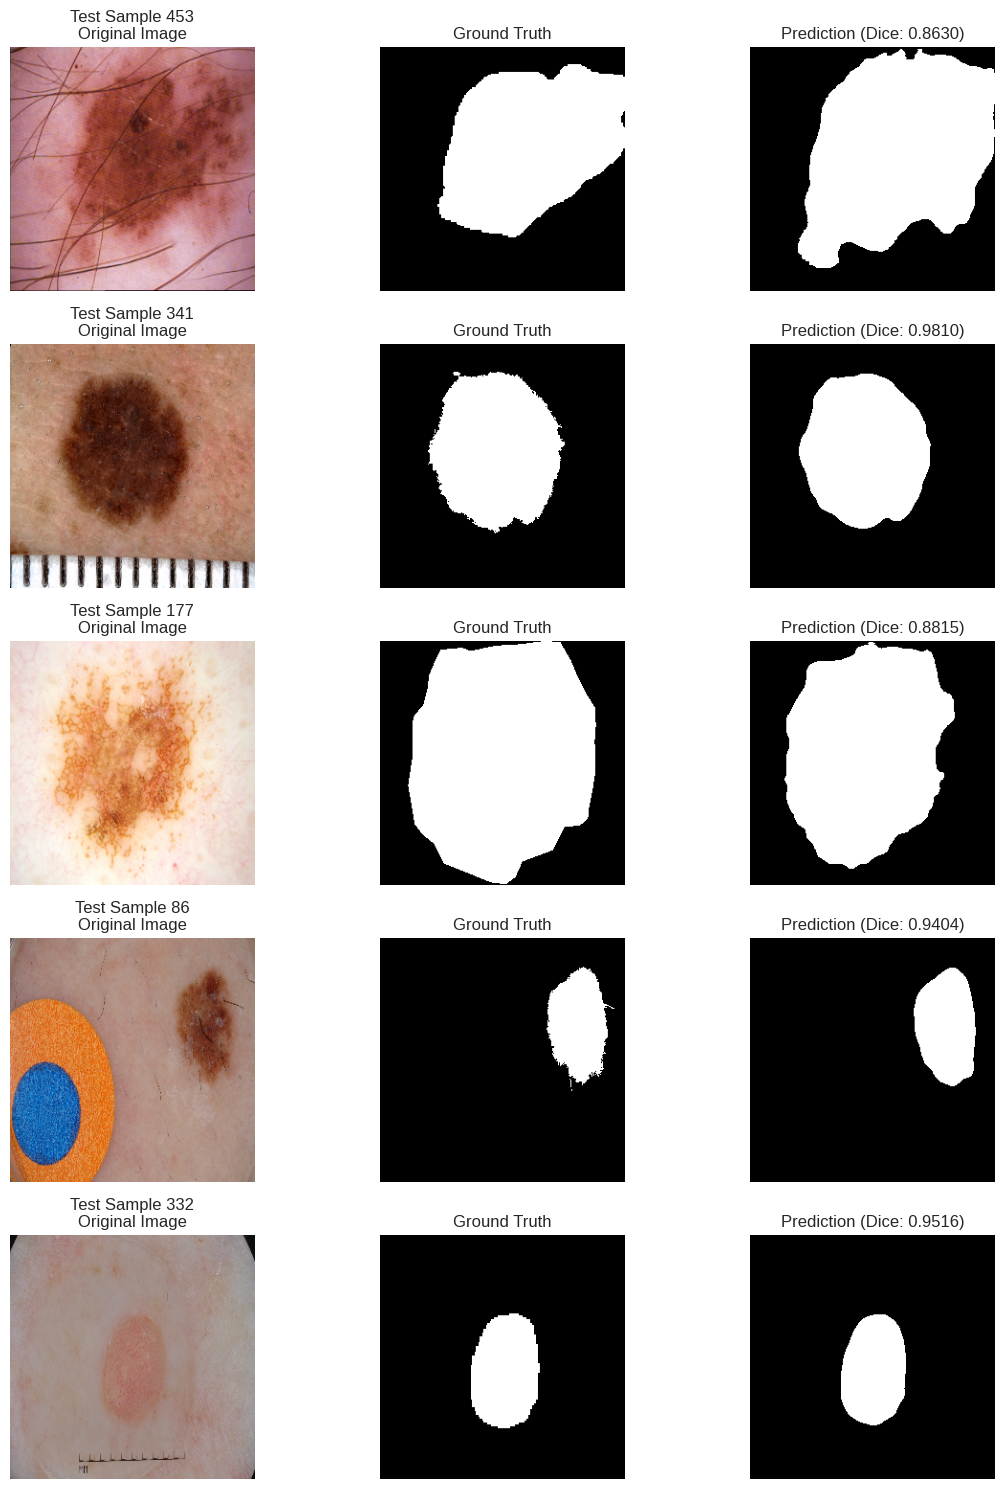

In [17]:
"""
Cell 16: Visualize Test Predictions
"""

def visualize_predictions(model, dataset, device, num_samples=5):
    """Visualize random test predictions"""
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))
    
    # Denormalization parameters
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Select random indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        
        # Prepare input for model
        input_tensor = image.unsqueeze(0).to(device)
        
        # Predict
        with torch.no_grad():
            # Use autocast for prediction
            with autocast(enabled=CONFIG['training']['mixed_precision']):
                logits = model(input_tensor)
            prob = torch.sigmoid(logits)
            pred_mask = (prob > 0.5).float().cpu().numpy().squeeze()
            
        # Prepare images for plotting
        # 1. Original Image
        img_np = image.numpy().transpose(1, 2, 0)
        img_np = (img_np * std + mean).clip(0, 1)
        
        # 2. Ground Truth
        gt_mask = mask.squeeze().numpy()
        
        # 3. Overlay (Green=GT, Red=Pred)
        # Create an RGB mask visualization
        vis_mask = np.zeros((*gt_mask.shape, 3))
        
        # Plotting
        # Column 1: Original Image
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Test Sample {idx}\nOriginal Image')
        axes[i, 0].axis('off')
        
        # Column 2: Ground Truth
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Column 3: Prediction
        axes[i, 2].imshow(pred_mask, cmap='gray')
        
        # Calculate Dice for this single image
        single_dice = dice_coefficient(logits, mask.unsqueeze(0).to(device))
        axes[i, 2].set_title(f'Prediction (Dice: {single_dice:.4f})')
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

print("📊 Visualizing random test predictions...")
visualize_predictions(model, test_dataset, device, num_samples=5)